In [1]:
import numpy as np

X = np.array([-1.93, -1.46, -0.87, -0.53, -0.29, -0.05], dtype=np.float64)
Y = np.array([18.3456, 19.9472, 21.91492, 21.8492, 23.1236, 25.8484], dtype=np.float64)
point = np.float64(-0.0)

In [2]:
def lagrange_interpolate(X: np.ndarray,
                         Y: np.ndarray,
                         point: np.float64) -> np.float64:

    n = X.shape[0]
    if n != Y.shape[0]:
        raise ValueError("X and Y must have the same length")

    result = np.float64(0.0)
    for i in range(n):
        term = Y[i]
        for j in range(n):
            if i == j:
                continue
            term *= (point - X[j]) / (X[i] - X[j])
        result += term

    return result

In [3]:
def aitken(X: np.ndarray,
           Y: np.ndarray,
           point: np.float64) -> np.float64:
    n = X.shape[0]
    if n != Y.shape[0]:
        raise ValueError(f"X len: {n} != Y len:{Y.shape[0]}")

    P = np.copy(Y.astype(np.float64))
    for k in range(1, n):
        for i in range(n - k):
            P[i] = ((point - X[i + k]) * P[i] - (point - X[i]) * P[i + 1]) / (X[i] - X[i + k])

    return P[0]

In [4]:
def newton_interpolate(X: np.ndarray,
                       Y: np.ndarray,
                       point: np.float64) -> np.float64:
    n = X.shape[0]
    if n != Y.shape[0]:
        raise ValueError("X and Y must have the same length")

    fdd = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        fdd[i][0] = Y[i]

    for j in range(1, n):
        for i in range(n - j):
            fdd[i][j] = (fdd[i+1][j-1] - fdd[i][j-1]) / (X[i+j] - X[i])

    result = fdd[0][0]
    for i in range(1, n):
        term = fdd[0][i]
        for j in range(i):
            term *= (point - X[j])
        result += term

    return result

In [5]:
print(f"lagrange: {lagrange_interpolate(X, Y, point)}")
print(f"aitken: {aitken(X, Y, point)}")
print(f"newton: {newton_interpolate(X, Y, point)}")

lagrange: 26.519558662617705
aitken: 26.519558662617698
newton: 26.519558662617687


In [6]:
from scipy.interpolate import lagrange

scipy_lagrange = lagrange(X, Y)
scipy_point= scipy_lagrange(point)
my_point = lagrange_interpolate(X, Y, point)

In [7]:
print(f"scipy lagrange: {scipy_point}")
print(f'my lagrange: {my_point}')
print(f"difference: {abs(scipy_point - my_point)}")

scipy lagrange: 26.519558662617705
my lagrange: 26.519558662617705
difference: 0.0


In [8]:
print(f"diff my lagrange and my aitken: {abs(scipy_point - aitken(X, Y, point))}")
print(f"diff my lagrange and my newton: {abs(scipy_point - newton_interpolate(X, Y, point))}")

diff my lagrange and my aitken: 7.105427357601002e-15
diff my lagrange and my newton: 1.7763568394002505e-14


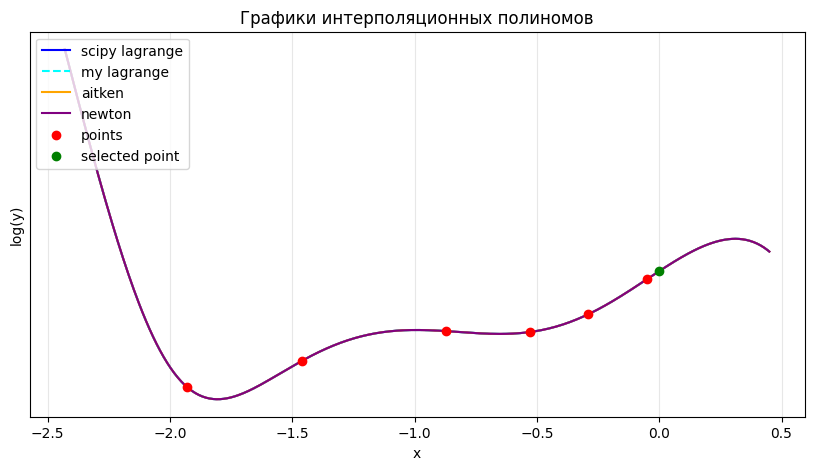

In [9]:
import matplotlib.pyplot as plt

x_range = np.linspace(X.min() - 0.5, X.max() + 0.5, 400)

y_scipy = scipy_lagrange(x_range)
y_lagrange = np.array([lagrange_interpolate(X, Y, x) for x in x_range])
y_aitken = np.array([aitken(X, Y, x) for x in x_range])
y_newton = np.array([newton_interpolate(X, Y, x) for x in x_range])

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x_range, y_scipy, color='blue', label='scipy lagrange')
ax1.plot(x_range, y_lagrange, color='cyan', linestyle='--', label='my lagrange')
ax1.plot(x_range, y_aitken, color='orange', label='aitken')
ax1.plot(x_range, y_newton, color='purple', label='newton')
ax1.scatter(X, Y, color='red', zorder=5, label='points')
ax1.scatter([point], [scipy_point], color='green', zorder=6, label='selected point')
ax1.set_yscale('symlog', linthresh=1e-2)
ax1.set_title('Графики интерполяционных полиномов')
ax1.set_ylabel('log(y)')
ax1.set_xlabel('x')
ax1.legend(loc='upper left')
ax1.grid(True, which='both', alpha=0.3)

plt.show()

In [10]:
x1, x2 = np.float64(-0.18), np.float64(-1.5)